### Import

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [12]:
df = pd.read_csv("../data/processed/rossmannV2.csv")

### Correlation

In [13]:
num_cols = df.select_dtypes(include="number").columns

In [14]:
corr_with_target = (
    df[num_cols].corr(method='spearman')["Sales"].drop('Sales')
)

I used spearman method because I wanna know does each feature tend to decrease or increase with Sales instead of linear correlation.

---

In [15]:
top_positive = corr_with_target.sort_values(ascending=False).head(10)
top_negative = corr_with_target.sort_values().head(10)

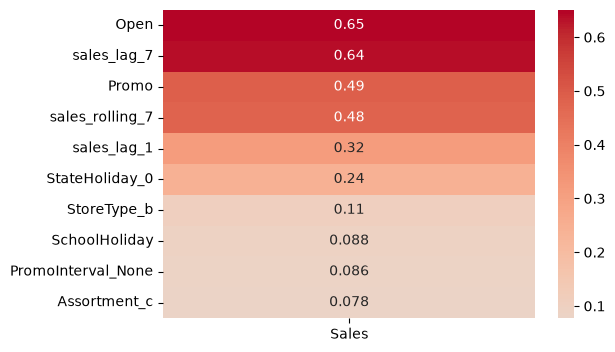

In [16]:
heatmap_data_pos = top_positive.to_frame(name="Sales")

plt.figure(figsize=(6, 4))
sns.heatmap(heatmap_data_pos, annot=True, center=0, cmap='coolwarm')

plt.show()

Based on top positive correlation heatmap I found out that Sales tend to increase if:
- There're `many customers` (corr was 0.95 and dropped on previous notebook)

- Store is `open`

And that's pretty obvious but there're also 3 insightful examples. Sales will increase if :
- Store is on `Promo`, which shows that promo works 

- If there's `no holiday` or it's a school holiday (students tend to go to store)

- And if `store type is B` (there's no certain information about it's exact meaning)

---

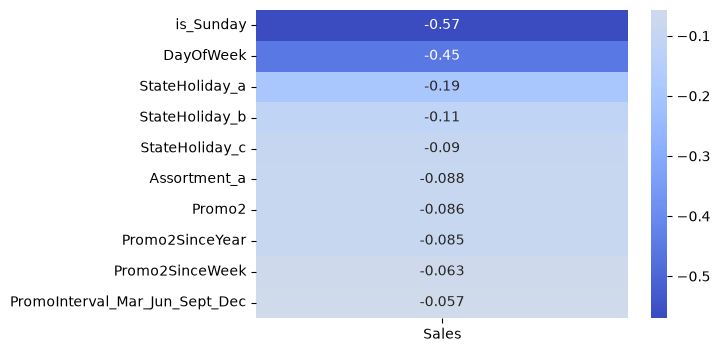

In [17]:
heatmap_data_neg = top_negative.to_frame(name="Sales")

plt.figure(figsize=(6, 4))
sns.heatmap(heatmap_data_neg, annot=True, center=0, cmap='coolwarm')

plt.show()

Based on top negative correlation heatmap I found out that Sales tend to decrease if:
- It's `Sunday` and `Day of week is High` which is easily explained by EU system -> Stores are closed on Sundays.

- Also if `there's a holiday` (especially A and B types which are `Public holiday and Easter`) and it's reasonable since Stores are also closed during those days.

- If assortment is type A -> Basic

- If store is participating in a `Second promotion` especially if it's runs during `March to December period`

---

### VIF

In [18]:
categorical_cols = [
    'PromoInterval_Mar,Jun,Sept,Dec',
    'PromoInterval_Jan,Apr,Jul,Oct',
    'PromoInterval_None',
    'Promo2',
    'StoreType_d',
    'StoreType_c',
    'StoreType_a',
    'StoreType_b',
    'Assortment_c',
    'Assortment_b',
    'Assortment_a',
    'PromoInterval_Feb,May,Aug,Nov',
    'StateHoliday_c',
    'StateHoliday_b',
    'StateHoliday_a',
    'StateHoliday_0'
]

numeric_cols = [
    col for col in df.select_dtypes("number").columns
    if col not in categorical_cols + ["Sales", "Store"]
]

Categorical features will return inf value in VIF so we have to seperate them from numerical columns

In [19]:
X = df[numeric_cols].dropna()

X_sample = X.sample(
    n=min(500_000, len(X)),
    random_state=42
)

Dataset is 1 million rows which increases time of compilation, so i decided to use sample instead

In [20]:
vif = pd.DataFrame({
    "feature": X_sample.columns,
    "VIF": [
        variance_inflation_factor(X_sample.to_numpy(), i)
        for i in range(X_sample.shape[1])
    ]
}).sort_values("VIF", ascending=False)

In [21]:
vif[vif['VIF'] > 8.0]

,feature,VIF
6,Promo2SinceYear,1.596900e+06
20,PromoInterval_Jan_Apr_Jul_Oct,9.204818e+05
19,PromoInterval_Feb_May_Aug_Nov,3.719480e+05
21,PromoInterval_Mar_Jun_Sept_Dec,3.054952e+05
11,month,6.942433e+01
13,week_of_year,6.232878e+01
10,year,6.165403e+01
1,Open,2.631311e+01
18,sales_rolling_7,2.537081e+01
0,DayOfWeek,1.734585e+01


There's a strong multicollinearity in three groups:
- `time-based features:` because they help to predict each other (year, month, etc.).

- `store activity features:` because store closed on Sundays (Open, is_Sunday, etc.)

- `sales dependencies:` relying on historical sales trend, causing spike in VIF (sales lag and rolling)

But it won't be a problem because I'll use tree-based model.

---

### Outliers

In [22]:
Q1 = df["Sales"].quantile(0.25)
Q3 = df["Sales"].quantile(0.75)
IQR = Q3 - Q1

outliers = df[
    (df["Sales"] < Q1 - 1.5 * IQR) |
    (df["Sales"] > Q3 + 1.5 * IQR)
]

In [23]:
print(f"Outliers: {len(outliers):,}")
print(f"Percentage: {len(outliers) / len(df) * 100:.2f}%")

Outliers: 26,559
Percentage: 2.63%


In [25]:
outliers[
    [
        "Store",
        "Sales",
        "Promo",
        "SchoolHoliday",
        "DayOfWeek"
    ]
].sort_values("Sales", ascending=False).head(20)

,Store,Sales,Promo,SchoolHoliday,DayOfWeek
821907,909,41551,0,0,1
236386,262,38722,1,0,5
236414,262,38484,1,0,5
236427,262,38367,0,1,4
51228,57,38037,1,0,1
738094,817,38025,1,0,1
234978,261,37646,1,0,1
236077,262,37403,0,0,4
235919,262,37376,0,0,7
236283,262,37122,0,0,7


In some outliers cases i noticed that there're:
- too few customers for such a big sales

- or there're just too many of customers

Threshold is above 4900 and under 1900 customers.

In [ ]:
df["is_outlier"] = df["Sales"].between(
    Q1 - 1.5 * IQR,
    Q3 + 1.5 * IQR
).eq(False)

df.groupby("is_outlier")[
    ["Sales", "Customers", "Promo"]
].agg(["mean", "median"])

Sales             Customers             Promo       
                    mean   median         mean  median      mean median
is_outlier                                                             
False        5473.094174   5657.0   597.346904   600.0  0.374280    0.0
True        17207.578297  16286.0  1986.989194  1834.0  0.719342    1.0

In [ ]:
df["SalesPerCustomer"] = df["Sales"] / df["Customers"].replace(0, np.nan)

In [ ]:
df["SalesPerCustomer"].describe()

count    838762.000000
mean          9.495752
std           2.197731
min           0.000000
25%           7.897611
50%           9.252191
75%          10.901955
max          64.957854
Name: SalesPerCustomer, dtype: float64

In [ ]:
df.nlargest(20, "SalesPerCustomer")[
    ["Store", "Sales", "Customers", "SalesPerCustomer", "Promo", 'StateHoliday_0', 
     'StateHoliday_a','StateHoliday_b','StateHoliday_c',]
]

,Store,Sales,Customers,SalesPerCustomer,Promo,StateHoliday_0,StateHoliday_a,StateHoliday_b,StateHoliday_c
810949,897,16954,261,64.957854,0,1,0,0,0
113668,126,33071,574,57.614983,1,1,0,0,0
113666,126,30619,554,55.268953,1,1,0,0,0
810832,897,17148,319,53.755486,0,1,0,0,0
113658,126,25049,475,52.734737,0,1,0,0,0
810964,897,11166,216,51.694444,0,1,0,0,0
810996,897,16558,331,50.024169,0,1,0,0,0
810819,897,11805,244,48.381148,1,1,0,0,0
810932,897,17649,386,45.722798,1,1,0,0,0
811013,897,15991,353,45.300283,1,1,0,0,0


In top 20 outliers sales per customer are 6 times higher than in regular values and there's no holiday

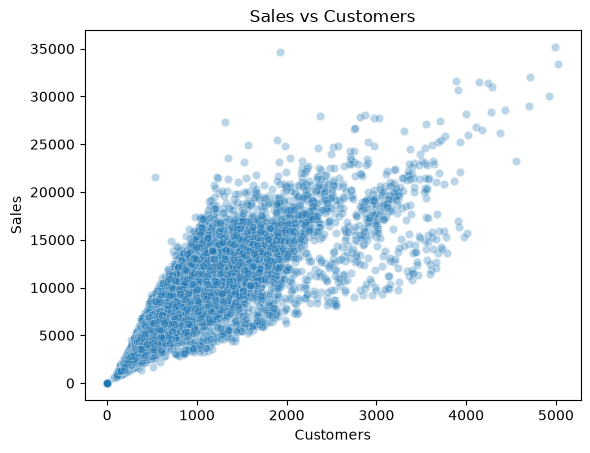

In [ ]:
sns.scatterplot(
    data=df.sample(50_000, random_state=42),
    x="Customers",
    y="Sales",
    alpha=0.3
)

plt.title("Sales vs Customers")
plt.show()

Sales contains substantial extreme values, but these observations should not automatically be removed because high sales can correspond to legitimate differences in store traffic, promotions, and temporal effects.

---

### Other data manipulation

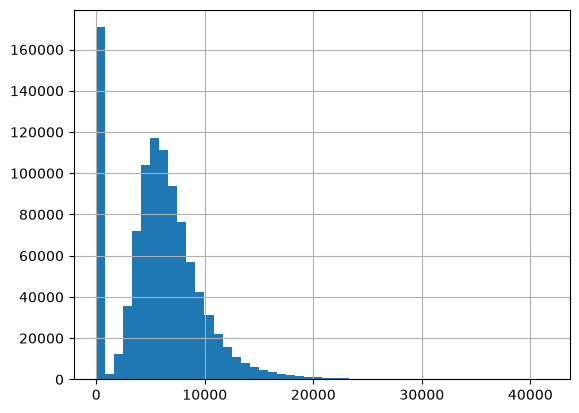

In [ ]:
df["Sales"].hist(bins=50)
plt.show()

As expected Sales is `right-skewed distributed` -> there are cases when store made 8 times more than usual.

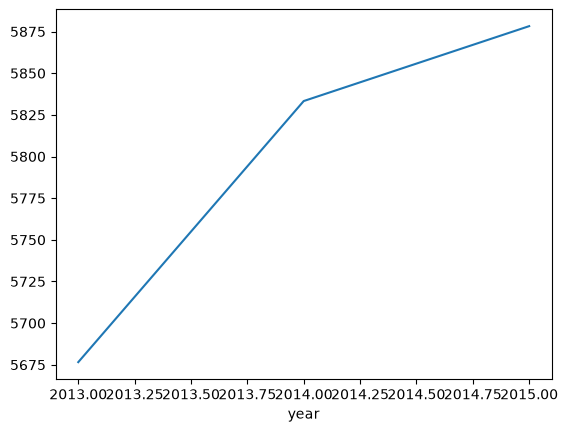

In [ ]:
df.groupby("year")["Sales"].mean().plot()
plt.show()

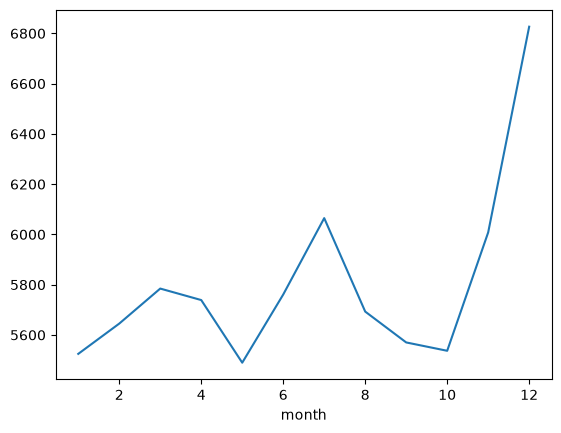

In [ ]:
df.groupby("month")["Sales"].mean().plot()
plt.show()

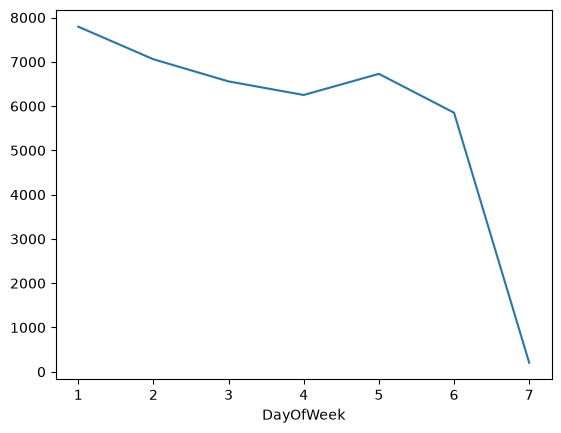

In [ ]:
df.groupby("DayOfWeek")["Sales"].mean().plot()
plt.show()

Based on those plots i can tell that:
- Sales grew up for `4% from 2013 to 2015.`

- The spike of sales can be expected during `June-July and October-December periods`.

- `Mondays, Tuesdays, Wednesdays and Fridays` are especially popular amoung customers.

---